<a href="https://colab.research.google.com/github/ajinfajrian/data-science-2026/blob/master/Pertemuan4_Fajrian_Ichlasul_240401020100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SEL 1: Langkah 1 – Load & Inspect Dataset

Instruksi: Memuat dataset Iris bawaan Seaborn, lalu menampilkan tipe data, dimensi, ringkasan deskriptif awal, dan 5 baris pertama data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load Dataset Iris resmi sesuai modul
df = sns.load_dataset('iris')

# 2. Inspeksi awal struktur data
print("--- Dimensi Dataset ---")
print(f"Shape: {df.shape} (Baris, Kolom)\n")

print("--- Tipe Data Kolom ---")
print(df.dtypes)

print("\n--- 5 Baris Pertama Data ---")
print(df.head())

--- Dimensi Dataset ---
Shape: (150, 5) (Baris, Kolom)

--- Tipe Data Kolom ---
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

--- 5 Baris Pertama Data ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


SEL 2: Langkah 2 – Statistik Deskriptif Lengkap

Instruksi: Menghitung ukuran pemusatan dan penyebaran data secara manual menggunakan fungsi Pandas/NumPy agar terlihat detail statistiknya.

In [4]:
# Menghitung statistik deskriptif untuk fitur numerik utama (contoh: sepal_length)
fitur = 'sepal_length'

print(f"--- Analisis Statistik Deskriptif: {fitur} ---")

# Membungkus fungsi dengan round() bawaan Python untuk menghindari AttributeError
print(f"Mean (Rata-rata)        : {round(df[fitur].mean(), 3)}")
print(f"Median (Nilai Tengah)   : {round(df[fitur].median(), 3)}")
print(f"Modus (Nilai Sering Ori): {round(df[fitur].mode()[0], 3)}")
print(f"Variance (Varians)      : {round(df[fitur].var(), 3)}")
print(f"Standar Deviasi         : {round(df[fitur].std(), 3)}")
print(f"Kuartil 1 (Q1 - 25%)    : {round(df[fitur].quantile(0.25), 3)}")
print(f"Kuartil 3 (Q3 - 75%)    : {round(df[fitur].quantile(0.75), 3)}")

# Menghitung IQR (Interquartile Range)
iqr = df[fitur].quantile(0.75) - df[fitur].quantile(0.25)
print(f"IQR                     : {round(iqr, 3)}")

--- Analisis Statistik Deskriptif: sepal_length ---
Mean (Rata-rata)        : 5.843
Median (Nilai Tengah)   : 5.8
Modus (Nilai Sering Ori): 5.0
Variance (Varians)      : 0.686
Standar Deviasi         : 0.828
Kuartil 1 (Q1 - 25%)    : 5.1
Kuartil 3 (Q3 - 75%)    : 6.4
IQR                     : 1.3


SEL 3: Langkah 3 – Analisis Distribusi (Histogram + KDE)

Instruksi: Membuat visualisasi distribusi frekuensi data numerik digabung dengan kurva estimasi kepadatan kernel (KDE) untuk melihat kemiringan (skewness) data.

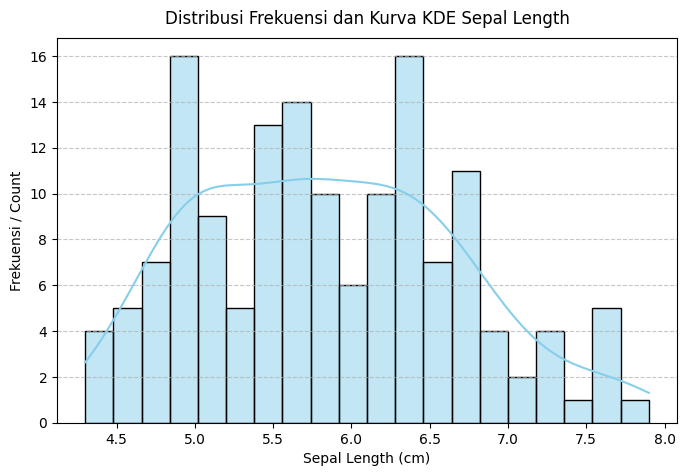

Nilai Skewness : 0.312
Nilai Kurtosis : -0.574


In [6]:
plt.figure(figsize=(8, 5))

# Membuat histogram dan kurva KDE menggunakan Seaborn
sns.histplot(data=df, x='sepal_length', kde=True, color='skyblue', bins=20)

plt.title('Distribusi Frekuensi dan Kurva KDE Sepal Length', fontsize=12, pad=10)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frekuensi / Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Menghitung skewness dan kurtosis menggunakan scipy.stats
print(f"Nilai Skewness : {stats.skew(df['sepal_length']):.3f}")
print(f"Nilai Kurtosis : {stats.kurtosis(df['sepal_length']):.3f}")

SEL 4: Langkah 4 – Boxplot per Spesies

Instruksi: Membuat boxplot untuk mendeteksi pencilan (outliers) dan membandingkan rentang nilai antar kelompok spesies bunga Iris (Setosa, Versicolor, Virginica).

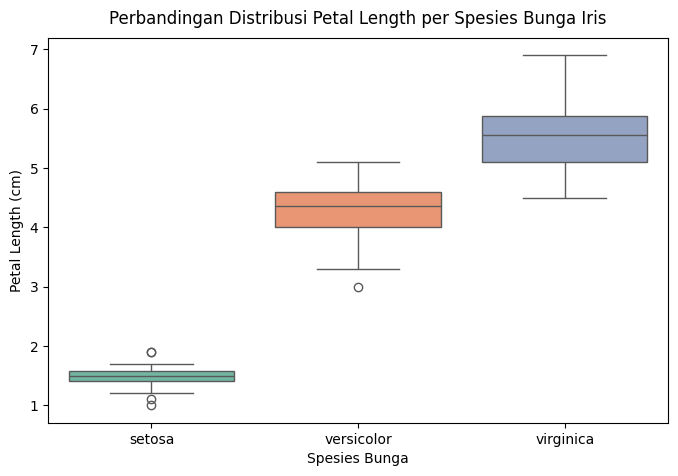

In [7]:
plt.figure(figsize=(8, 5))

# Membuat boxplot komparasi antar spesies
sns.boxplot(data=df, x='species', y='petal_length', hue='species', palette='Set2', legend=False)

plt.title('Perbandingan Distribusi Petal Length per Spesies Bunga Iris', fontsize=12, pad=10)
plt.xlabel('Spesies Bunga')
plt.ylabel('Petal Length (cm)')
plt.show()

SEL 5: Langkah 5 – Scatter Plot Hubungan Dua Variabel

Instruksi: Melakukan analisis bivariat menggunakan scatter plot untuk melihat korelasi tren spasial sebaran titik antar dua fitur numerik.

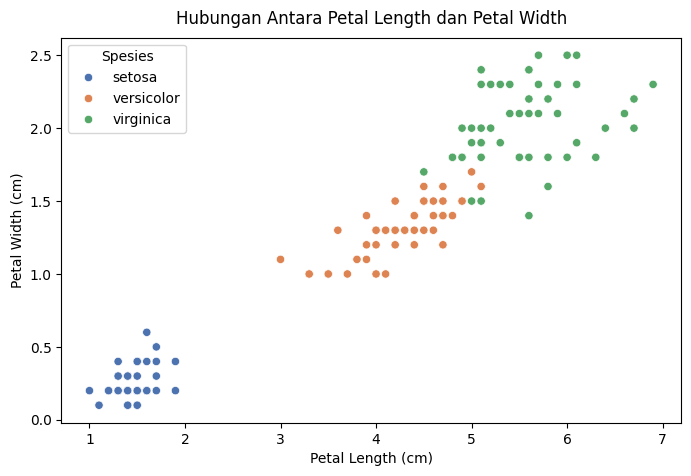

In [8]:
plt.figure(figsize=(8, 5))

# Membuat scatter plot hubungan panjang vs lebar mahkota (petal) bunga
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='deep')

plt.title('Hubungan Antara Petal Length dan Petal Width', fontsize=12, pad=10)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Spesies')
plt.show()

SEL 6: Langkah 6 – Heatmap Korelasi Matriks

Instruksi: Menghitung koefisien korelasi Pearson antar seluruh kolom numerik dan memvisualisasikannya ke dalam bentuk Heatmap matriks warna.

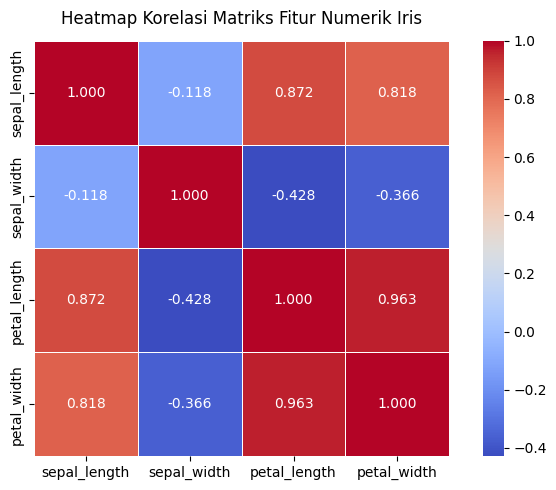

In [9]:
plt.figure(figsize=(7, 5))

# 1. Menghitung korelasi matriks hanya untuk kolom bertipe numerik saja
kolom_numerik = df.select_dtypes(include=[np.number])
korelasi_matriks = kolom_numerik.corr(method='pearson')

# 2. Visualisasi dengan heatmap warna Seaborn
sns.heatmap(korelasi_matriks, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, square=True)

plt.title('Heatmap Korelasi Matriks Fitur Numerik Iris', fontsize=12, pad=12)
plt.tight_layout()
plt.show()